
# Airbnb NYC Mini-Project: From Data Insight to Prediction
Nama: Naman Salwan

Course: DASC-4850-A-Data Science and AI in Python

Date: 20 April, 2026
## Research goal
Predict Airbnb nightly price in New York City and test whether **Entire home/apt** listings have a different average price than **Private room** listings.

## Dataset
The dataset contains Airbnb listings in New York City, including variables such as price, location, room type, availability, and reviews. It contains over 48,000 observations, which satisfies the project requirements.



## 1. Imports


In [57]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams["figure.figsize"] = (7, 4.5)

os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)



## 2. Load data and inspect the original shape


In [58]:

df = pd.read_csv("AB_NYC_2019.csv")
print("Original shape:", df.shape)
df.head()


Original shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0



## 3. Data wrangling and feature engineering

I used the following meaningful processing steps:

1. Removed duplicate rows.
2. Removed invalid or unrealistic values:
   - price must be greater than 0
   - minimum_nights must be between 1 and 365
   - extreme price outliers above the 99th percentile were removed
3. Filled missing `reviews_per_month` values with 0.
4. Converted `last_review` to datetime and created `days_since_last_review`.
5. Created two extra binary features:
   - `has_reviews`
   - `host_is_multi_listing`
6. Created `log_price = log1p(price)` for more stable regression modelling.


In [59]:

clean = df.drop_duplicates().copy()
clean = clean[clean["price"].notna() & (clean["price"] > 0)]
clean = clean[clean["minimum_nights"].between(1, 365)]

price_cap = clean["price"].quantile(0.99)
clean = clean[clean["price"] <= price_cap]

clean["reviews_per_month"] = clean["reviews_per_month"].fillna(0)

clean["last_review"] = pd.to_datetime(clean["last_review"], errors="coerce")
ref_date = clean["last_review"].max()
clean["days_since_last_review"] = (ref_date - clean["last_review"]).dt.days
max_days = clean["days_since_last_review"].max()
clean["days_since_last_review"] = clean["days_since_last_review"].fillna(max_days + 30)

clean["has_reviews"] = (clean["number_of_reviews"] > 0).astype(int)
clean["host_is_multi_listing"] = (clean["calculated_host_listings_count"] > 1).astype(int)
clean["log_price"] = np.log1p(clean["price"])

print("Final shape after cleaning:", clean.shape)
clean.head()


Final shape after cleaning: (48396, 20)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review,has_reviews,host_is_multi_listing,log_price
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,262.0,1,1,5.010635
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,48.0,1,1,5.420535
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365,3054.0,0,0,5.017280
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,3.0,1,0,4.499810
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,231.0,1,0,4.394449



## 4. Descriptive statistics


In [60]:

desc = clean[[
    "price","latitude","longitude","minimum_nights","number_of_reviews",
    "reviews_per_month","calculated_host_listings_count","availability_365",
    "days_since_last_review"
]].describe().round(2)

desc.to_csv("tables/descriptive_statistics.csv")
desc


,price,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review
count,48396.00,48396.00,48396.00,48396.00,48396.00,48396.00,48396.00,48396.00,48396.00
mean,137.58,40.73,-73.95,6.79,23.42,1.10,7.18,112.04,839.94
std,103.78,0.05,0.05,16.13,44.71,1.60,33.10,131.23,1176.45
min,10.00,40.50,-74.24,1.00,0.00,0.00,1.00,0.00,0.00
25%,69.00,40.69,-73.98,1.00,1.00,0.04,1.00,0.00,19.00
50%,105.00,40.72,-73.96,3.00,5.00,0.38,1.00,44.00,185.00
75%,175.00,40.76,-73.94,5.00,24.00,1.60,2.00,224.00,1174.00
max,799.00,40.91,-73.71,365.00,629.00,58.50,327.00,365.00,3054.00



## 5. Exploratory Data Analysis


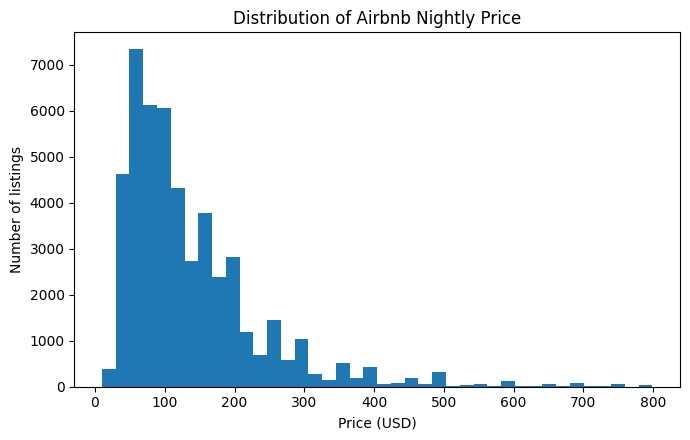

In [61]:

# Plot 1: histogram of price
plt.figure()
clean["price"].plot(kind="hist", bins=40)
plt.title("Distribution of Airbnb Nightly Price")
plt.xlabel("Price (USD)")
plt.ylabel("Number of listings")
plt.tight_layout()
plt.savefig("figures/price_histogram.png", dpi=200)
plt.show()



**Interpretation:** The price distribution is strongly right-skewed. Most NYC listings are in the low-to-mid price range, while a smaller number of listings are much more expensive.


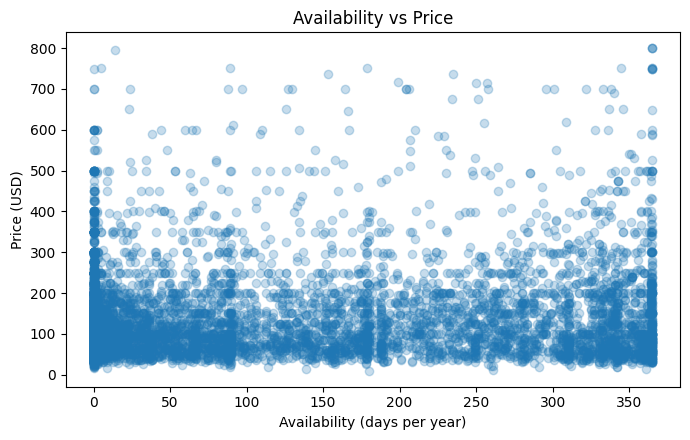

In [62]:

# Plot 2: availability vs price
sample = clean.sample(min(8000, len(clean)), random_state=42)

plt.figure()
plt.scatter(sample["availability_365"], sample["price"], alpha=0.25)
plt.title("Availability vs Price")
plt.xlabel("Availability (days per year)")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.savefig("figures/availability_vs_price.png", dpi=200)
plt.show()



**Interpretation:** There is no strong straight-line relationship between availability and price, but highly available listings still show a wide range of prices.


<Figure size 700x450 with 0 Axes>

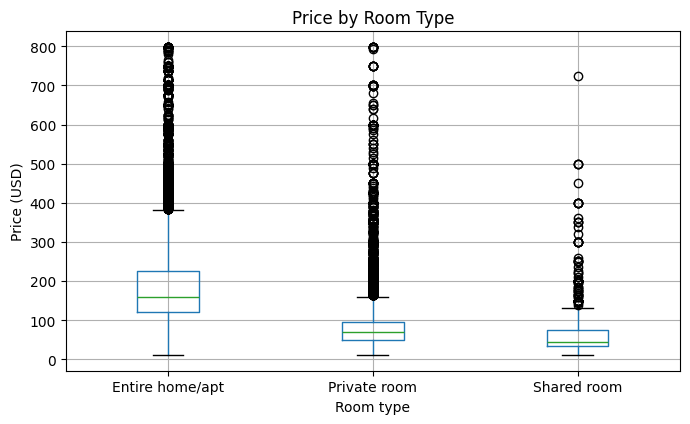

In [63]:

# Plot 3: boxplot by room type
plt.figure()
clean.boxplot(column="price", by="room_type")
plt.title("Price by Room Type")
plt.suptitle("")
plt.xlabel("Room type")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.savefig("figures/price_by_room_type_boxplot.png", dpi=200)
plt.show()



**Interpretation:** Entire home/apartment listings have a much higher median price than private rooms and shared rooms. The spread is also much wider for entire-home listings.


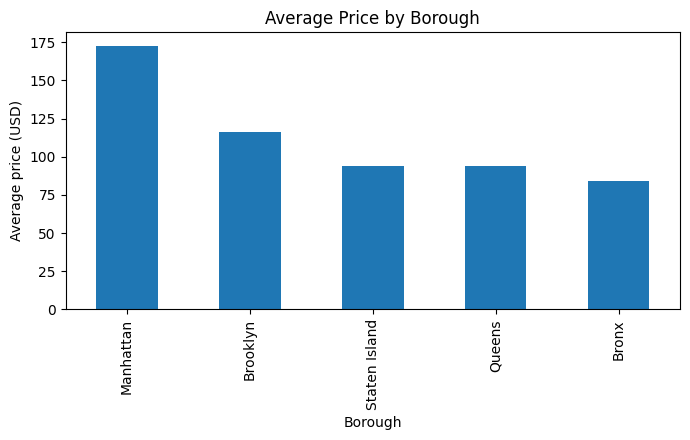

In [64]:

# Plot 4: average price by borough
avg_price = clean.groupby("neighbourhood_group", observed=False)["price"].mean().sort_values(ascending=False)

plt.figure()
avg_price.plot(kind="bar")
plt.title("Average Price by Borough")
plt.xlabel("Borough")
plt.ylabel("Average price (USD)")
plt.tight_layout()
plt.savefig("figures/average_price_by_borough.png", dpi=200)
plt.show()



**Interpretation:** Manhattan has the highest average listing price by a clear margin. This suggests location is an important driver of Airbnb pricing in NYC.


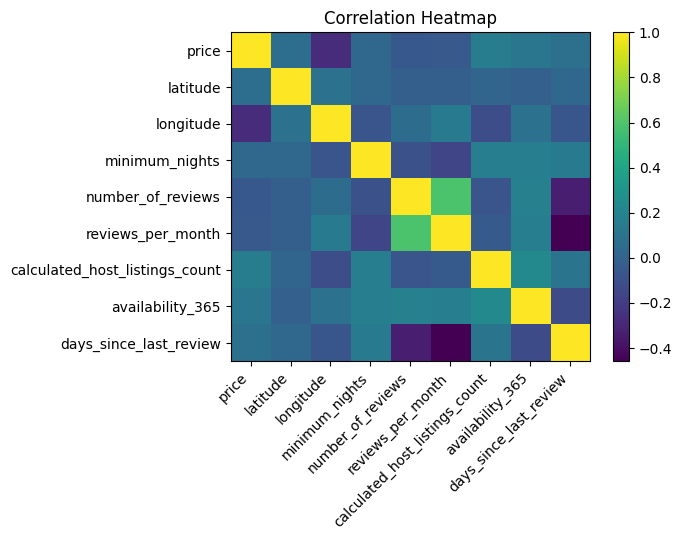

price                             1.000
calculated_host_listings_count    0.151
availability_365                  0.113
days_since_last_review            0.077
latitude                          0.067
minimum_nights                    0.029
reviews_per_month                -0.053
number_of_reviews                -0.056
longitude                        -0.274
Name: price, dtype: float64

In [65]:

# Correlation analysis
corr = clean[[
    "price","latitude","longitude","minimum_nights","number_of_reviews",
    "reviews_per_month","calculated_host_listings_count","availability_365",
    "days_since_last_review"
]].corr()

corr["price"].sort_values(ascending=False).round(3).to_csv(
    "tables/price_correlations.csv", header=["correlation_with_price"]
)

plt.figure(figsize=(7, 5.5))
im = plt.imshow(corr, aspect="auto")
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=200)
plt.show()

corr["price"].sort_values(ascending=False).round(3)



**Interpretation:** Price has moderate positive correlation with longitude and availability, while review-related variables are weakly negatively related to price. Numeric predictors alone are not enough; location and room type matter too.



## 6. Statistical Question

**Question:** Is there a significant difference in price between entire homes and private rooms?

**Test used:** Welch two-sample t-test

**Why this test:** We are comparing the mean price of two independent groups, and Welch's version does not assume equal group variances.


In [66]:

entire = clean.loc[clean["room_type"] == "Entire home/apt", "price"]
private = clean.loc[clean["room_type"] == "Private room", "price"]

ttest = stats.ttest_ind(entire, private, equal_var=False)

n1, n2 = len(entire), len(private)
mean1, mean2 = entire.mean(), private.mean()
mean_diff = mean1 - mean2

s1, s2 = entire.var(ddof=1), private.var(ddof=1)
se = np.sqrt(s1/n1 + s2/n2)
df_welch = (s1/n1 + s2/n2)**2 / ((s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1))
ci_low = mean_diff - stats.t.ppf(0.975, df_welch) * se
ci_high = mean_diff + stats.t.ppf(0.975, df_welch) * se

sp = np.sqrt(((n1-1)*s1 + (n2-1)*s2) / (n1+n2-2))
cohen_d = mean_diff / sp

stats_table = pd.DataFrame([{
    "group_1": "Entire home/apt",
    "n1": n1,
    "mean_1": mean1,
    "group_2": "Private room",
    "n2": n2,
    "mean_2": mean2,
    "mean_difference": mean_diff,
    "t_statistic": ttest.statistic,
    "p_value": ttest.pvalue,
    "ci_low": ci_low,
    "ci_high": ci_high,
    "cohens_d": cohen_d
}]).round(4)

stats_table.to_csv("tables/statistical_test_results.csv", index=False)
stats_table


,group_1,n1,mean_1,group_2,n2,mean_2,mean_difference,t_statistic,p_value,ci_low,ci_high,cohens_d
0,Entire home/apt,25013,189.1047,Private room,22233,83.3997,105.705,132.1999,0.0,104.1378,107.2722,1.1799



**Plain-language conclusion:** Entire home/apartment listings are priced much higher on average than private rooms. The difference is statistically significant, and the effect size is large.



## 7. Predictive Modelling

I use **Ridge regression** with a preprocessing pipeline that:
- scales numeric variables
- one-hot encodes categorical variables

### Target
The final business target is `price`, but the model is fit on `log_price` to reduce skewness. Predictions are converted back to dollars before evaluation.

### Split
- 60% train
- 20% validation
- 20% test


In [67]:

features = [
    "neighbourhood_group","room_type","latitude","longitude","minimum_nights",
    "number_of_reviews","reviews_per_month","calculated_host_listings_count",
    "availability_365","days_since_last_review","has_reviews","host_is_multi_listing"
]

X = clean[features]
y = clean["log_price"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

cat_cols = ["neighbourhood_group", "room_type"]
num_cols = [c for c in features if c not in cat_cols]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])


In [68]:

alphas = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
tuning_rows = []

best_rmse = float("inf")
best_alpha = None
best_model = None

for alpha in alphas:
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("ridge", Ridge(alpha=alpha))
    ])
    model.fit(X_train, y_train)

    val_pred = np.expm1(model.predict(X_val))
    val_true = np.expm1(y_val)

    rmse = mean_squared_error(val_true, val_pred) ** 0.5
    mae = mean_absolute_error(val_true, val_pred)

    tuning_rows.append({"alpha": alpha, "validation_rmse": rmse, "validation_mae": mae})

    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = alpha
        best_model = model
        best_mae = mae

tuning_df = pd.DataFrame(tuning_rows).round(4)
tuning_df.to_csv("tables/model_tuning_results.csv", index=False)
tuning_df


,alpha,validation_rmse,validation_mae
0,0.01,84.2049,48.8919
1,0.10,84.2051,48.8919
2,1.00,84.2074,48.8922
3,10.00,84.2303,48.8947
4,50.00,84.3275,48.9171
5,100.00,84.4380,48.9537


In [69]:

test_pred = np.expm1(best_model.predict(X_test))
test_true = np.expm1(y_test)

test_rmse = mean_squared_error(test_true, test_pred) ** 0.5
test_mae = mean_absolute_error(test_true, test_pred)

performance = pd.DataFrame([
    {"split": "validation", "RMSE": best_rmse, "MAE": best_mae},
    {"split": "test", "RMSE": test_rmse, "MAE": test_mae}
]).round(4)

performance.to_csv("tables/model_performance.csv", index=False)

print("Best alpha:", best_alpha)
performance


Best alpha: 0.01


,split,RMSE,MAE
0,validation,84.2049,48.8919
1,test,82.8275,47.5751



## 8. Model interpretation


In [70]:

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
coef_series = pd.Series(best_model.named_steps["ridge"].coef_, index=feature_names)
top_coefs = coef_series.sort_values(key=np.abs, ascending=False).head(12).round(4)

top_coefs.to_csv("tables/top_coefficients.csv", header=["coefficient"])
top_coefs


cat__neighbourhood_group_Staten Island   -0.6596
cat__room_type_Entire home/apt            0.6223
cat__room_type_Shared room               -0.5072
cat__neighbourhood_group_Manhattan        0.3527
cat__neighbourhood_group_Queens           0.1714
num__longitude                           -0.1286
cat__room_type_Private room              -0.1151
num__availability_365                     0.0893
cat__neighbourhood_group_Brooklyn         0.0716
num__has_reviews                         -0.0645
cat__neighbourhood_group_Bronx            0.0638
num__minimum_nights                      -0.0603
dtype: float64


**Interpretation of important coefficients:**
- `room_type_Entire home/apt` has a strong positive coefficient, meaning entire-home listings tend to have higher expected prices.
- `room_type_Shared room` has a strong negative coefficient, meaning shared rooms are generally cheaper.
- `neighbourhood_group_Manhattan` is positively associated with price, which matches the EDA.
- Higher `minimum_nights` is slightly associated with lower price after controlling for other variables.



## 9. Conclusion, limitation, and next step

### Main conclusion
The dataset shows a clear pricing gap across room types and boroughs. Entire-home listings and Manhattan locations are especially associated with higher prices.

### Limitation
This model does not include text information such as listing title, amenities, quality of photos, or host response behavior. Those omitted factors likely affect price.

### Next step
A good next step would be to compare Ridge regression with tree-based models such as Random Forest or XGBoost.



## 10. AI Use Appendix
AI tools were used for project planning, structuring the notebook, and improving explanation clarity.  
All numerical results were verified by running the code and checking the saved tables and figures.
